## Trees

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

In [154]:
md= pd.read_csv('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/data/processed/marine_data_cleaned.csv')
md.head()

,STUDY_ID,LATITUDE,LONGITUDE,species_richness,total_abundance,mean_depth,n_samples,n_years,year_start,year_end,...,precip_proxy,log_area,sampling_intensity,depth_category,coastal_proxy,temp_squared,temp_x_precip,latitude_squared,productivity_proxy,log_richness
0,164,37.81020,-122.32300,13,126.0,1.000000,3,2,2000,2001,...,1463.318708,2.944439,1.5,shallow,1,123.096806,16235.374733,1429.611224,16.235375,-0.305382
1,245,50.85045,3.61936,9,50.0,-6.267057,6,2,2009,2010,...,1133.244839,2.944439,3.0,shallow,1,20.928566,5184.340160,2585.768265,5.184340,-0.641854
2,245,50.88528,3.69284,6,49.0,-6.267057,3,2,2009,2010,...,1311.765920,2.944439,1.5,shallow,1,20.769530,5978.189531,2589.311721,5.978190,-0.998529
3,245,50.91131,3.41330,15,1106.0,-6.267057,15,2,2007,2008,...,1330.386822,2.944439,7.5,shallow,1,20.651071,6045.736701,2591.961486,6.045737,-0.171850
4,245,50.91145,3.41317,15,420.0,-6.267057,15,2,2007,2008,...,1041.224731,2.944439,7.5,shallow,1,20.650435,4731.611515,2591.975741,4.731612,-0.171850


## Feature sets

In [155]:
features_density = [
    'mean_depth',
    'LATITUDE',
    'abs_latitude',
    'LONGITUDE',
    'dist_from_equator_km',
    'temp_proxy',
    'temp_range_proxy',
    'precip_proxy',
    'sampling_intensity',
    'coastal_proxy',
    'temp_squared',
    'temp_x_precip',
    'latitude_squared',
    'productivity_proxy'
]
 
# ecological variables only
features_no_sampling = [
    'mean_depth',
    'abs_latitude',
    'LATITUDE',
    'LONGITUDE',
    'dist_from_equator_km',
    'temp_proxy',
    'temp_range_proxy',
    'precip_proxy',
    'coastal_proxy',
    'temp_squared',
    'temp_x_precip',
    'latitude_squared',
    'productivity_proxy'
]


Target Variable + Feature Matrices + Train/Test Splits


In [156]:
# identify species density target, rename for interpretability
md['log_density'] = md['log_richness'] 

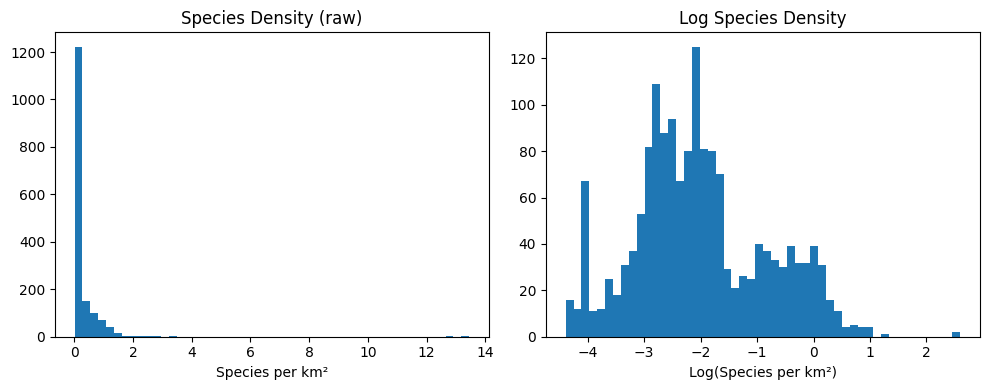

In [157]:
# compare raw density and log density
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# exponentiate species dens to show original
md['raw_density']=np.exp(md['log_density'])

plt.hist((md['raw_density']), bins=50)
plt.title('Species Density (raw)')
plt.xlabel('Species per km²')

plt.subplot(1, 2, 2)
plt.hist(md['log_density'], bins=50)
plt.title('Log Species Density')
plt.xlabel('Log(Species per km²)')
plt.tight_layout()
plt.savefig('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/Images/distribution_comparison_dens.png', dpi=150, bbox_inches='tight')
plt.show()


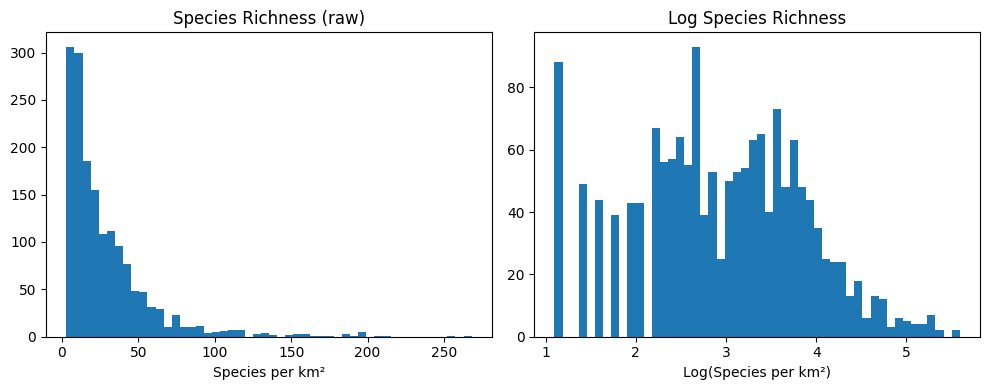

In [158]:
# compare raw richness and log richnes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(md['species_richness'], bins=50)
plt.title('Species Richness (raw)')
plt.xlabel('Species per km²')

plt.subplot(1, 2, 2)
plt.hist(np.log(md['species_richness']), bins=50)
plt.title('Log Species Richness')
plt.xlabel('Log(Species per km²)')
plt.tight_layout()
plt.savefig('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/Images/distribution_comparison_richness_rich.png', dpi=150, bbox_inches='tight')
plt.show()


In [159]:
# Log transform of density chosen — more symmetric distribution
y_density = md['log_density']
print("Target range:", y_density.min().round(3), "to", y_density.max().round(3))
print("Target mean:", y_density.mean().round(3))

Target range: -4.391 to 2.599
Target mean: -2.028


In [160]:
# Feature matrices
X_main = md[features_density].to_numpy()
X_nosamp = md[features_no_sampling].to_numpy()

In [161]:
# Train/test splits
X_train, X_test, y_train, y_test = train_test_split(X_main, y_density, test_size=0.2, random_state=0)

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(X_nosamp, y_density, test_size=0.2, random_state=0)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1295
Test size: 324


## From Scratch Dec Tree

In [162]:
# lower weighted variance = purer groups = better split
def weighted_variance(left, right):
    n_total = len(left) + len(right)
    weight_left = len(left) / n_total
    weight_right = len(right) / n_total
    return (weight_left * np.var(left)) + (weight_right * np.var(right))


In [163]:
# searches all features and thresholds to find the split minimizing weighted variance
def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_score = float('inf')
 
    if len(y) < 2:
        return None, None, float('inf')
 
    n_features = X.shape[1]
 
    for feature_idx in range(n_features):
        thresholds = np.unique(X[:, feature_idx])
 
        for threshold in thresholds:
            left_mask = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
 
            left_y = y[left_mask]
            right_y = y[right_mask]
 
            if len(left_y) == 0 or len(right_y) == 0:
                continue
 
            score = weighted_variance(left_y, right_y)
 
            if score < best_score:
                best_feature = feature_idx
                best_threshold = threshold
                best_score = score
 
    return best_feature, best_threshold, best_score


In [164]:
# recursively builds the tree  and stops at max_depth or min_samples_leaf
def build_tree(X, y, depth=0, max_depth=10, min_samples_leaf=5):
 
    # Stopping conditions to return a leaf node
    if depth >= max_depth or len(y) < min_samples_leaf:
        return {'value': np.mean(y)}
 
    feature, threshold, score = best_split(X, y)
 
    if feature is None:
        return {'value': np.mean(y)}
 
    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask
 
    left_subtree = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth, min_samples_leaf)
    right_subtree = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth, min_samples_leaf)
 
    return {
        'feature': feature,
        'threshold': threshold,
        'left': left_subtree,
        'right': right_subtree
    }
 

#  makes tree for one site
def predict_one(node, row):
    if 'value' in node:
        return node['value']
    if row[node['feature']] <= node['threshold']:
        return predict_one(node['left'], row)
    else:
        return predict_one(node['right'], row)
 
# predicts for all sites
def predict(node, X):
    return np.array([predict_one(node, row) for row in X])


# Compare Models

In [165]:
# From-scratch tree
tree_scratch = build_tree(X_train, y_train, max_depth=10, min_samples_leaf=5)
y_pred_scratch = predict(tree_scratch, X_test)
rmse_scratch = np.sqrt(mean_squared_error(y_test, y_pred_scratch))
r2_scratch = r2_score(y_test, y_pred_scratch)
 
# Sklearn tree to validate from-scratch implementation
sklearn_tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=0)
sklearn_tree.fit(X_train, y_train)
y_pred_sk = sklearn_tree.predict(X_test)
rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
r2_sk = r2_score(y_test, y_pred_sk)
 
# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=0)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


In [ ]:
def calculate_aic(y_true, y_pred, k):
    n = len(y_true)
    residuals = y_true - y_pred
    rss = np.sum(residuals ** 2)
    aic = n * np.log(rss / n) + 2 * k
    return aic

k_main = len(features_density) + 1 

aic_scratch = calculate_aic(y_test, y_pred_scratch, k_main)
aic_sk = calculate_aic(y_test, y_pred_sk, k_main)
aic_rf = calculate_aic(y_test, y_pred_rf, k_main)

In [167]:
print("Target: Log Species Density (no log_area)")
print(f"{'Model':<25} {'RMSE':>8} {'R²':>8} {'AIC':>8}")
print(f"{'From-scratch Tree':<25} {rmse_scratch:>8.3f} {r2_scratch:>8.3f} {aic_scratch:>8.3f}")
print(f"{'Sklearn Tree':<25} {rmse_sk:>8.3f} {r2_sk:>8.3f} {aic_sk:>8.3f}")
print(f"{'Random Forest':<25} {rmse_rf:>8.3f} {r2_rf:>8.3f} {aic_ns:>8.3f}")

Target: Log Species Density (no log_area)
Model                         RMSE       R²      AIC
From-scratch Tree            0.733    0.585 -170.957
Sklearn Tree                 0.670    0.654 -229.679
Random Forest                0.626    0.697 -250.822


In [151]:
# RF with 10-fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=0)
 
cv_scores = cross_val_score(rf, X_main, y_density, cv=kf, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
 
cv_r2 = cross_val_score(rf, X_main, y_density, cv=kf, scoring='r2')
 
print("10-Fold Cross Validation — Random Forest")
print(f"  RMSE per fold: {cv_rmse.round(3)}")
print(f"  Mean RMSE:     {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"\n  R² per fold:   {cv_r2.round(3)}")
print(f"  Mean R²:       {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")


10-Fold Cross Validation — Random Forest
  RMSE per fold: [0.575 0.697 0.634 0.592 0.662 0.669 0.635 0.57  0.664 0.682]
  Mean RMSE:     0.638 ± 0.043

  R² per fold:   [0.724 0.651 0.659 0.742 0.672 0.659 0.716 0.736 0.702 0.702]
  Mean R²:       0.696 ± 0.032


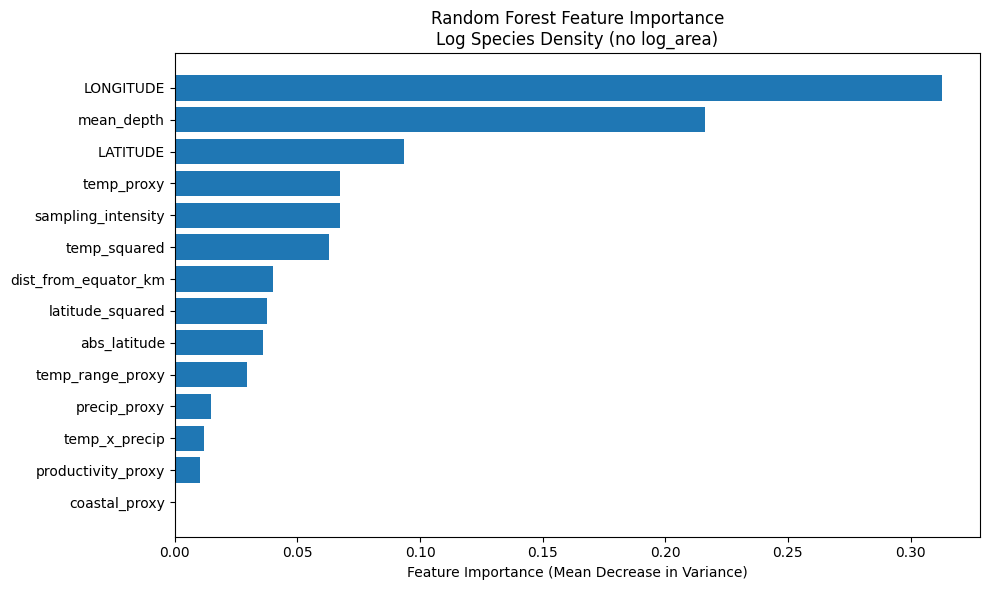

In [128]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features_density[i] for i in indices[::-1]],
         importances[indices[::-1]])
ax.set_xlabel('Feature Importance (Mean Decrease in Variance)')
ax.set_title('Random Forest Feature Importance\nLog Species Density (no log_area)')
plt.tight_layout()
plt.savefig('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/Images/feature_importance_main.png', dpi=150, bbox_inches='tight')
plt.show()


# Now use only ecological variables

In [172]:
rf_ns = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=0)
rf_ns.fit(X_train_ns, y_train_ns)
y_pred_ns = rf_ns.predict(X_test_ns)
k_eco=len(features_no_sampling)+1

rmse_ns = np.sqrt(mean_squared_error(y_test_ns, y_pred_ns))
r2_ns = r2_score(y_test_ns, y_pred_ns)
aic_ns = calculate_aic(y_test_ns, y_pred_ns, k_eco)
 
print("Robustness Check (ecological vars only)")
print(f"{'Model':<35} {'RMSE':>8} {'R²':>8}")
print(f"{'Full model (with sampling_intensity)':<35} {rmse_rf:>8.3f} {r2_rf:>8.3f} {aic_rf:>8.3f}")
print(f"{'Ecological model (no sampling)':<35} {rmse_ns:>8.3f} {r2_ns:>8.3f} {aic_ns:>8.3f}")


Robustness Check (ecological vars only)
Model                                   RMSE       R²
Full model (with sampling_intensity)    0.626    0.697 -273.557
Ecological model (no sampling)         0.650    0.673 -250.822


In [ ]:
cv_r2_ns = cross_val_score(rf_ns, X_nosamp, y_density, cv=kf, scoring='r2')
cv_rmse_ns = np.sqrt(-cross_val_score(rf_ns, X_nosamp, y_density, cv=kf, scoring='neg_mean_squared_error'))

print("10-Fold CV for Ecological Model (no sampling_intensity)")
print(f"  Mean RMSE: {cv_rmse_ns.mean():.3f} ± {cv_rmse_ns.std():.3f}")
print(f"  Mean R²:   {cv_r2_ns.mean():.3f} ± {cv_r2_ns.std():.3f}")

10-Fold CV — Ecological Model (no sampling_intensity)
  Mean RMSE: 0.657 ± 0.044
  Mean R²:   0.678 ± 0.034


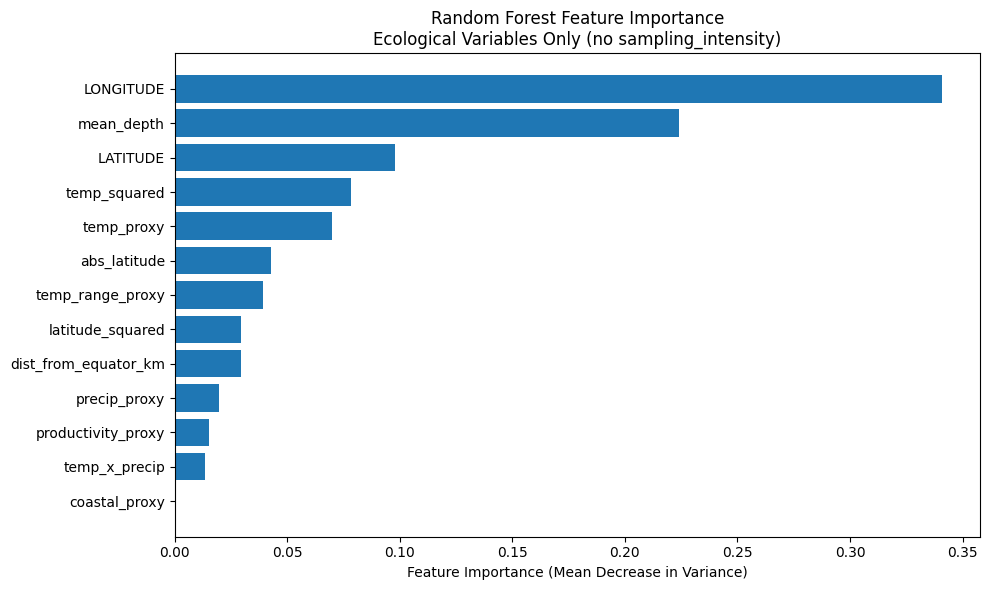

In [130]:
importances_ns = rf_ns.feature_importances_
indices_ns = np.argsort(importances_ns)[::-1]
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features_no_sampling[i] for i in indices_ns[::-1]],
         importances_ns[indices_ns[::-1]])
ax.set_xlabel('Feature Importance (Mean Decrease in Variance)')
ax.set_title('Random Forest Feature Importance\nEcological Variables Only (no sampling_intensity)')
plt.tight_layout()
plt.savefig('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/Images/feature_importance_ecological.png', dpi=150, bbox_inches='tight')
plt.show()
 


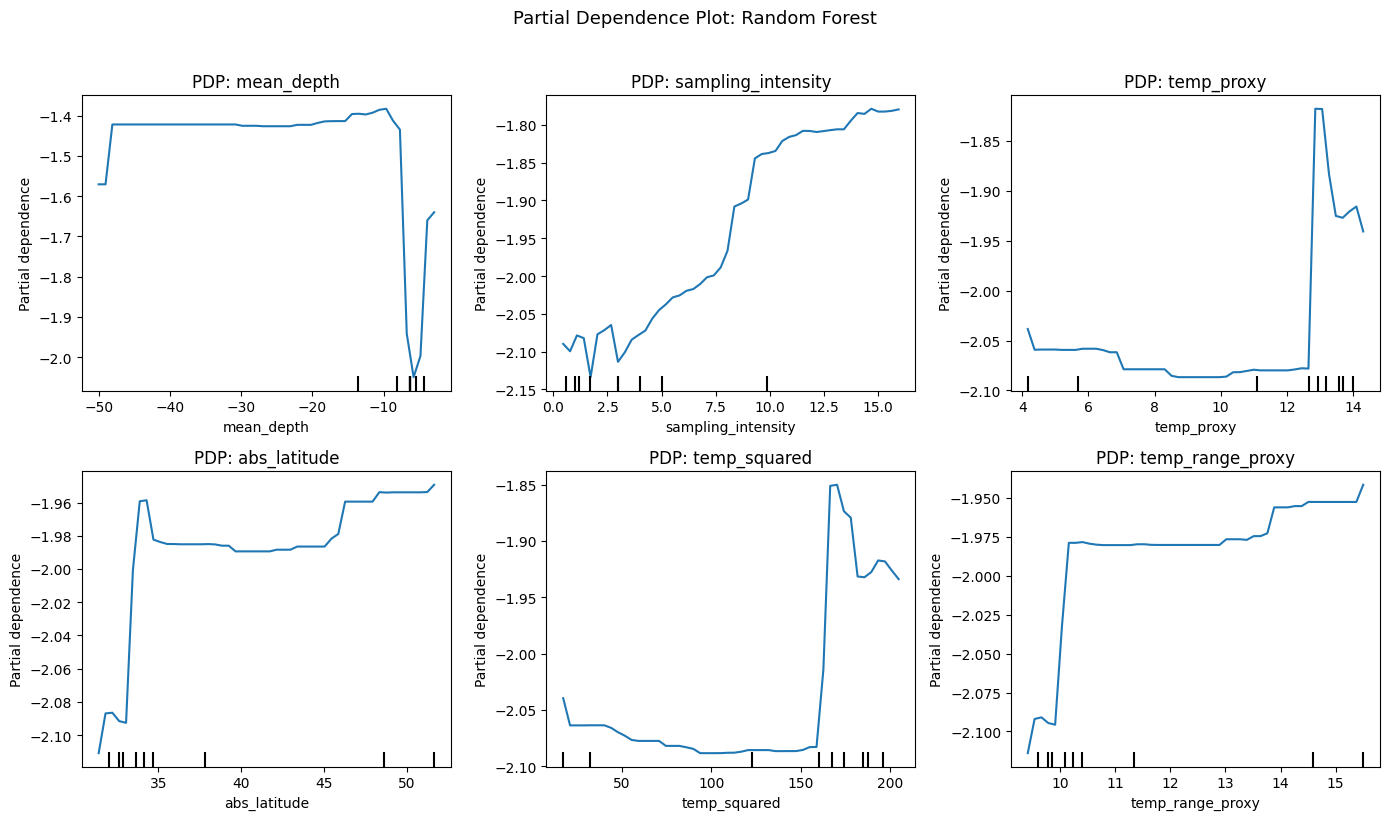

In [173]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
 
features_to_plot = ['mean_depth', 'sampling_intensity', 'temp_proxy',
                    'abs_latitude', 'temp_squared', 'temp_range_proxy']
 
for i, feat_name in enumerate(features_to_plot):
    ax = axes[i // 3][i % 3]
    PartialDependenceDisplay.from_estimator(
        rf, X_train, [feat_name],
        feature_names=features_density,
        ax=ax, grid_resolution=50
    )
    ax.set_title(f'PDP: {feat_name}')
    ax.set_ylabel('Log Species Density')
 
plt.suptitle('Partial Dependence Plot: Random Forest',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/Images/pdp_plots.png', dpi=150, bbox_inches='tight')
plt.show()


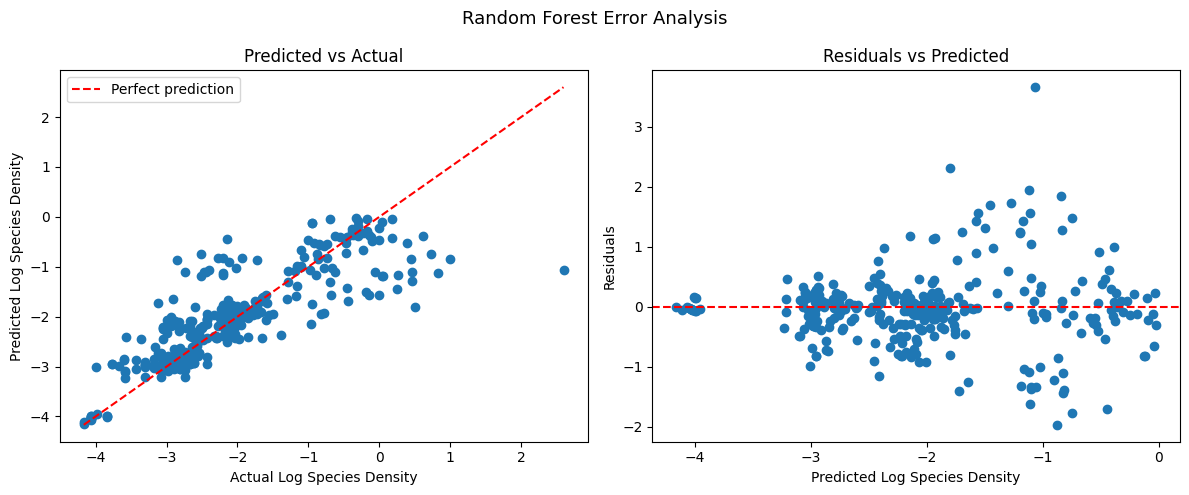

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Predicted vs actual
axes[0].scatter(y_test, y_pred_rf)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Log Species Density')
axes[0].set_ylabel('Predicted Log Species Density')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
 
# Residuals vs predicted
residuals = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Log Species Density')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')
 
plt.suptitle('Random Forest Error Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/Images/residuals.png', dpi=150, bbox_inches='tight')
plt.show()


### Species Richness Models original target


In [133]:
# features including log_area for species richness prediction
features_richness = features_density +['log_area']

X_rich = md[features_richness].to_numpy()
y_rich = md['species_richness'].to_numpy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_rich, y_rich, test_size=0.2, random_state=0)

rf_rich = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                min_samples_leaf=5, random_state=0)
rf_rich.fit(X_train_r, y_train_r)
y_pred_rich = rf_rich.predict(X_test_r)

rmse_rich = np.sqrt(mean_squared_error(y_test_r, y_pred_rich))
r2_rich = r2_score(y_test_r, y_pred_rich)

print("Target: Raw Species Richness")
print(f"  RMSE: {rmse_rich:.3f}")
print(f"  R²:   {r2_rich:.3f}")

Target: Raw Species Richness
  RMSE: 15.181
  R²:   0.779


# Removing Log Area from feature set
Since its not a environmental predictor, it may not be relevant and may overpower ie. doesnt help our outcome.

In [134]:
# Raw richness WITHOUT log_area — fair comparison
X_rich_no_logarea = md[features_density].to_numpy()  # same 12 features as log density

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_rich_no_logarea, y_rich, test_size=0.2, random_state=0
)

rf_rich2 = RandomForestRegressor(n_estimators=100, max_depth=10,
                                 min_samples_leaf=5, random_state=0)
rf_rich2.fit(X_train_r2, y_train_r2)
y_pred_rich2 = rf_rich2.predict(X_test_r2)

r2_rich2 = r2_score(y_test_r2, y_pred_rich2)
print(f"Raw richness WITH log_area:    R² = {r2_rich:.3f}")
print(f"Raw richness WITHOUT log_area: R² = {r2_rich2:.3f}")
print(f"Log density WITHOUT log_area:  R² = {r2_rf:.3f}")

Raw richness WITH log_area:    R² = 0.779
Raw richness WITHOUT log_area: R² = 0.723
Log density WITHOUT log_area:  R² = 0.697


In [135]:
# 10-fold CV comparison across all three target variations
kf = KFold(n_splits=10, shuffle=True, random_state=0)

# Raw richness with log_area
cv_r2_rich_with = cross_val_score(rf_rich, X_rich, y_rich, cv=kf, scoring='r2')

# Raw richness without log_area
cv_r2_rich_without = cross_val_score(rf_rich2, X_rich_no_logarea, y_rich, cv=kf, scoring='r2')

# Log density without log_area
cv_r2_density = cross_val_score(rf, X_main, y_density, cv=kf, scoring='r2')


In [136]:

print("10-Fold CV R² Comparison")
print(f"\n{'Target':<35} {'Single Split R²':>16} {'CV Mean R²':>12} {'CV Std':>8}")
print(f"{'Raw richness WITH log_area':<35} {r2_rich:>16.3f} {cv_r2_rich_with.mean():>12.3f} {cv_r2_rich_with.std():>8.3f}")
print(f"{'Raw richness WITHOUT log_area':<35} {r2_rich2:>16.3f} {cv_r2_rich_without.mean():>12.3f} {cv_r2_rich_without.std():>8.3f}")
print(f"{'Log density WITHOUT log_area':<35} {r2_rf:>16.3f} {cv_r2_density.mean():>12.3f} {cv_r2_density.std():>8.3f}")

10-Fold CV R² Comparison

Target                               Single Split R²   CV Mean R²   CV Std
Raw richness WITH log_area                     0.779        0.773    0.045
Raw richness WITHOUT log_area                  0.723        0.701    0.040
Log density WITHOUT log_area                   0.697        0.696    0.032


In [137]:
def print_tree(node, feature_names, depth=0, max_depth=3):
    indent = "    " * depth
    if 'value' in node:
        print(f"{indent}→ predict: {node['value']:.3f}")
        return
    if depth >= max_depth:
        print(f"{indent}...")
        return
    feature_name = feature_names[node['feature']]
    print(f"{indent}if {feature_name} <= {node['threshold']:.3f}:")
    print_tree(node['left'], feature_names, depth + 1, max_depth)
    print(f"{indent}else:")
    print_tree(node['right'], feature_names, depth + 1, max_depth)
 
print("From-Scratch Decision Tree Structure (top 3 levels):")
print("=" * 50)
print_tree(tree_scratch, features_density, max_depth=3)


From-Scratch Decision Tree Structure (top 3 levels):
if abs_latitude <= 33.165:
    if LONGITUDE <= 35.104:
        if LONGITUDE <= -81.229:
            ...
        else:
            ...
    else:
        if LATITUDE <= -12.400:
            ...
        else:
            ...
else:
    if mean_depth <= -61.627:
        if mean_depth <= -97.475:
            ...
        else:
            ...
    else:
        if abs_latitude <= 34.472:
            ...
        else:
            ...


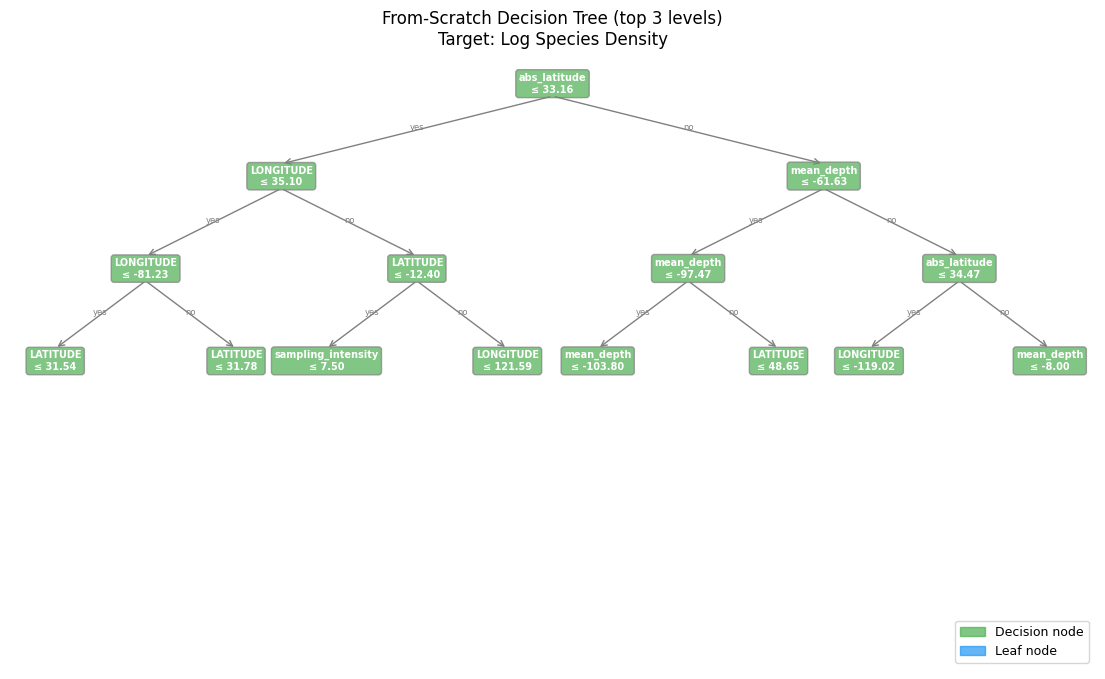

In [138]:
def plot_tree_dict(node, feature_names, ax, x=0.5, y=0.95,
                   dx=0.25, dy=0.15, depth=0, max_depth=3):
    if depth > max_depth:
        return
    if 'value' in node:
        text = f"predict\n{node['value']:.2f}"
        color = '#2196F3'
    else:
        feature_name = feature_names[node['feature']]
        text = f"{feature_name}\n≤ {node['threshold']:.2f}"
        color = '#4CAF50'
    ax.text(x, y, text, ha='center', va='center',
            fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3',
                     facecolor=color, alpha=0.7, edgecolor='gray'),
            color='white', fontweight='bold')
    if 'value' in node or depth >= max_depth:
        return
    x_left = x - dx / (depth + 1)
    y_left = y - dy
    ax.annotate('', xy=(x_left, y_left + 0.02), xytext=(x, y - 0.02),
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.text((x + x_left) / 2, (y + y_left) / 2, 'yes', fontsize=6, color='gray', ha='center')
    plot_tree_dict(node['left'], feature_names, ax, x_left, y_left, dx, dy, depth + 1, max_depth)
    x_right = x + dx / (depth + 1)
    y_right = y - dy
    ax.annotate('', xy=(x_right, y_right + 0.02), xytext=(x, y - 0.02),
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.text((x + x_right) / 2, (y + y_right) / 2, 'no', fontsize=6, color='gray', ha='center')
    plot_tree_dict(node['right'], feature_names, ax, x_right, y_right, dx, dy, depth + 1, max_depth)
 
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plot_tree_dict(tree_scratch, features_density, ax, max_depth=3)
green = mpatches.Patch(color='#4CAF50', alpha=0.7, label='Decision node')
blue = mpatches.Patch(color='#2196F3', alpha=0.7, label='Leaf node')
ax.legend(handles=[green, blue], loc='lower right', fontsize=9)
plt.title('From-Scratch Decision Tree (top 3 levels)\nTarget: Log Species Density', fontsize=12)
plt.show()
 


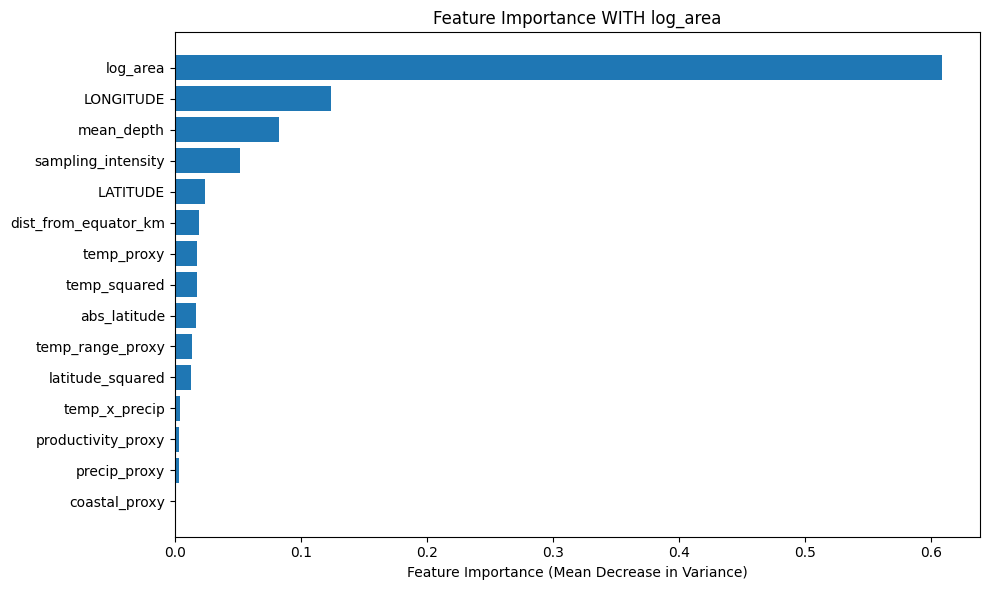

In [139]:
# Build feature matrix WITH log_area for comparison
features_with_logarea = features_density + ['log_area']
X_logarea = md[features_with_logarea].to_numpy()
X_train_la, X_test_la, y_train_la, y_test_la = train_test_split(
    X_logarea, y_density, test_size=0.2, random_state=0
)
rf_la = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=0)
rf_la.fit(X_train_la, y_train_la)
 
importances_la = rf_la.feature_importances_
indices_la = np.argsort(importances_la)[::-1]
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features_with_logarea[i] for i in indices_la[::-1]],
         importances_la[indices_la[::-1]])
ax.set_xlabel('Feature Importance (Mean Decrease in Variance)')
ax.set_title('Feature Importance WITH log_area')
plt.tight_layout()
plt.savefig('/Users/juliannahoitt/Desktop/MATH6243/FinalProj/Biodiversity-Predictors/Images/feature_importance_with_logarea.png', dpi=150, bbox_inches='tight')
plt.show()
